Sample mean   : 0.030
95% CI mean   : (-0.391, 0.658)
Sample median : -0.050
95% CI median : (-0.489, 0.235)


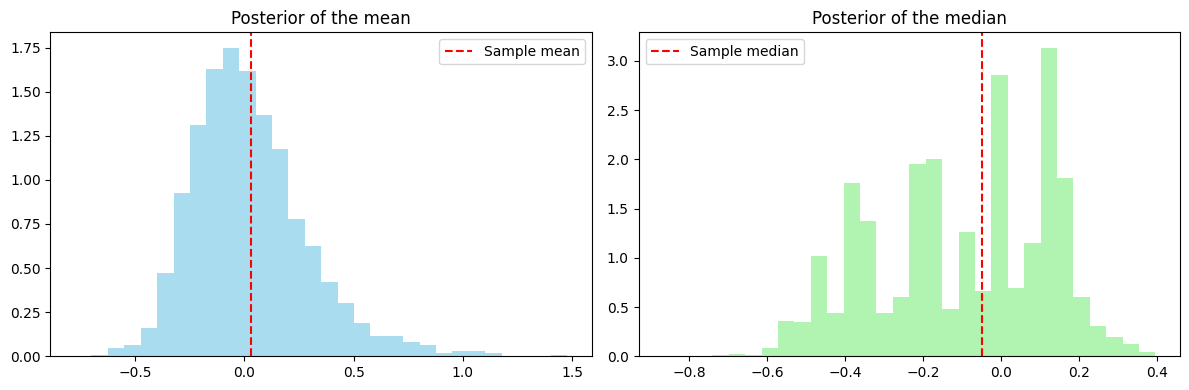

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import npest

np.random.seed(42)
data = np.random.standard_t(df=5, size=100)
bb = npest.BayesianBootstrap(n_resamples=5000).fit(data)
ci_mean = bb.confidence_interval(np.mean, alpha=0.05)
ci_median = bb.confidence_interval(np.median, alpha=0.05)

print(f"Sample mean   : {np.mean(data):.3f}")
print(f"95% CI mean   : ({ci_mean[0]:.3f}, {ci_mean[1]:.3f})")
print(f"Sample median : {np.median(data):.3f}")
print(f"95% CI median : ({ci_median[0]:.3f}, {ci_median[1]:.3f})")
post_means = bb.sample_statistic(np.mean)
post_medians = bb.sample_statistic(np.median)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(post_means, bins=30, density=True, alpha=0.7, color='skyblue')
ax1.axvline(np.mean(data), color='red', linestyle='--', label='Sample mean')
ax1.set_title('Posterior of the mean')
ax1.legend()

ax2.hist(post_medians, bins=30, density=True, alpha=0.7, color='lightgreen')
ax2.axvline(np.median(data), color='red', linestyle='--', label='Sample median')
ax2.set_title('Posterior of the median')
ax2.legend()

plt.tight_layout()
plt.show()